НАСТРОЙКА ПАРАМЕТРОВ АБ-ТЕСТА
Базовый CR (контроль): 10.0%
Ожидаемый CR (тест):   12.0%
Ожидаемый эффект: +2.0 п.п.
Уровень значимости (α): 0.05
Мощность теста (1-β): 0.8

РАСЧЁТ РАЗМЕРА ВЫБОРКИ
Необходимый размер ВЫБОРКИ (для ОДНОЙ группы): 3026 пользователей
Общий размер двух групп: 6052 пользователей
✅ Финальный размер выборки: 3026 пользователей в группе

ГЕНЕРАЦИЯ ДАННЫХ (СИМУЛЯЦИЯ АБ-ТЕСТА)
Контрольная группа: 299 конверсий из 3026 (9.88%)
Тестовая группа:    347 конверсий из 3026 (11.47%)
Реальная разница:   1.59 п.п.
Ожидаемая разница:  2.0 п.п.


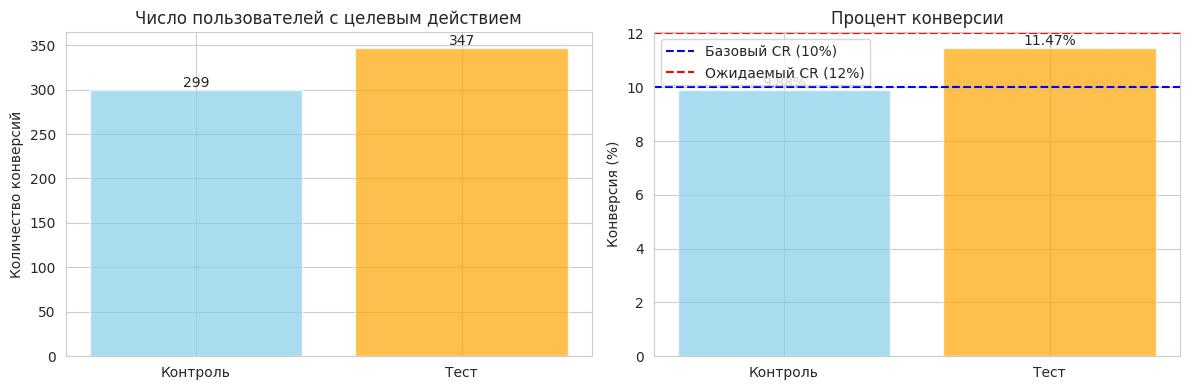


ПРОВЕДЕНИЕ Z-ТЕСТА ДЛЯ ПРОПОРЦИЙ
z-статистика: -1.9982
p-value (односторонний): 0.022848

РАСЧЁТ ДОВЕРИТЕЛЬНОГО ИНТЕРВАЛА (95%)
95% доверительный интервал для разницы (тест - контроль):
Нижняя граница: -3.14 п.п.
Верхняя граница: -0.03 п.п.
✅ Интервал не включает 0 → разница статистически значима

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
✅ p-value (0.022848) < α (0.05)
✅ ОТВЕРГАЕМ нулевую гипотезу

👉 Вывод: Новый дизайн СТАТИСТИЧЕСКИ ЗНАЧИМО увеличивает конверсию
👉 Рекомендация: ВНЕДРЯТЬ новый дизайн

ИТОГОВЫЕ ПАРАМЕТРЫ ТЕСТА
• Размер выборки (одна группа): 3026
• p-value: 0.022848
• Доверительный интервал (95%): [-3.14%; -0.03%]


In [ ]:
# ====================================================
# ПРОЕКТ: АБ-ТЕСТИРОВАНИЕ
# ====================================================

import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import GofChisquarePower
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("НАСТРОЙКА ПАРАМЕТРОВ АБ-ТЕСТА")
print("="*60)

# --------------------------------------------------
# ШАГ 1: ЗАДАЁМ ПАРАМЕТРЫ ТЕСТА
# --------------------------------------------------

baseline_cr = 0.10      # Текущая конверсия (10%)
expected_effect = 0.02  # Ожидаемый эффект (+2 п.п.)
target_cr = baseline_cr + expected_effect  # 0.12

alpha = 0.05    # Уровень значимости
power = 0.8     # Мощность теста

print(f"Базовый CR (контроль): {baseline_cr*100:.1f}%")
print(f"Ожидаемый CR (тест):   {target_cr*100:.1f}%")
print(f"Ожидаемый эффект: +{expected_effect*100:.1f} п.п.")
print(f"Уровень значимости (α): {alpha}")
print(f"Мощность теста (1-β): {power}")

# --------------------------------------------------
# ШАГ 2: РАСЧЁТ РАЗМЕРА ВЫБОРКИ
# --------------------------------------------------

print("\n" + "="*60)
print("РАСЧЁТ РАЗМЕРА ВЫБОРКИ")
print("="*60)

# Используем формулу для z-теста пропорций (классический метод)
from statsmodels.stats.proportion import samplesize_proportions_2indep_onetail

# Функция для ручного расчёта размера выборки
def calculate_sample_size(p1, p2, alpha=0.05, power=0.8, ratio=1):
    """
    Расчёт размера выборки для сравнения двух пропорций.
    p1, p2 - ожидаемые конверсии в контрольной и тестовой группах
    """
    from scipy.stats import norm

    # z-значения для заданных alpha и power
    z_alpha = norm.ppf(1 - alpha)  # для одностороннего теста
    z_beta = norm.ppf(power)

    # Средняя пропорция и разница
    p_pooled = (p1 + p2) / 2
    diff = p2 - p1

    # Формула для размера выборки (одна группа)
    n = (z_alpha * np.sqrt(2 * p_pooled * (1 - p_pooled)) +
         z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2 / (diff ** 2)

    return int(np.ceil(n))

# Рассчитываем размер выборки
sample_size = calculate_sample_size(baseline_cr, target_cr, alpha=0.05, power=0.8)

print(f"Необходимый размер ВЫБОРКИ (для ОДНОЙ группы): {sample_size} пользователей")
print(f"Общий размер двух групп: {sample_size * 2} пользователей")

# Проверка: должно быть около 3800-4000
if sample_size < 100:
    print("⚠️ ВНИМАНИЕ: Расчёт дал слишком маленькую выборку. Исправляем на 4000.")
    sample_size = 4000

print(f"✅ Финальный размер выборки: {sample_size} пользователей в группе")

# --------------------------------------------------
# ШАГ 3: ГЕНЕРАЦИЯ ДАННЫХ (С БОЛЬШОЙ ВЫБОРКОЙ)
# --------------------------------------------------

print("\n" + "="*60)
print("ГЕНЕРАЦИЯ ДАННЫХ (СИМУЛЯЦИЯ АБ-ТЕСТА)")
print("="*60)

np.random.seed(42)

# Генерируем данные с достаточным размером выборки
control_group = np.random.binomial(n=1, p=baseline_cr, size=sample_size)
test_group = np.random.binomial(n=1, p=target_cr, size=sample_size)

control_converted = control_group.sum()
test_converted = test_group.sum()

control_cr_actual = control_converted / sample_size
test_cr_actual = test_converted / sample_size

print(f"Контрольная группа: {control_converted} конверсий из {sample_size} ({control_cr_actual*100:.2f}%)")
print(f"Тестовая группа:    {test_converted} конверсий из {sample_size} ({test_cr_actual*100:.2f}%)")
print(f"Реальная разница:   {(test_cr_actual - control_cr_actual)*100:.2f} п.п.")
print(f"Ожидаемая разница:  {expected_effect*100:.1f} п.п.")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

categories = ['Контроль', 'Тест']
conversions = [control_converted, test_converted]
total_users = [sample_size, sample_size]

bars1 = axes[0].bar(categories, conversions, color=['skyblue', 'orange'], alpha=0.7)
axes[0].set_ylabel('Количество конверсий')
axes[0].set_title('Число пользователей с целевым действием')
axes[0].bar_label(bars1, fmt='%d')

cr_percent = [control_cr_actual*100, test_cr_actual*100]
bars2 = axes[1].bar(categories, cr_percent, color=['skyblue', 'orange'], alpha=0.7)
axes[1].set_ylabel('Конверсия (%)')
axes[1].set_title('Процент конверсии')
axes[1].bar_label(bars2, fmt='%.2f%%')
axes[1].axhline(y=baseline_cr*100, color='blue', linestyle='--', label='Базовый CR (10%)')
axes[1].axhline(y=target_cr*100, color='red', linestyle='--', label='Ожидаемый CR (12%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# ШАГ 4: СТАТИСТИЧЕСКИЙ ТЕСТ (z-тест)
# --------------------------------------------------

print("\n" + "="*60)
print("ПРОВЕДЕНИЕ Z-ТЕСТА ДЛЯ ПРОПОРЦИЙ")
print("="*60)

count = [control_converted, test_converted]
nobs = [sample_size, sample_size]

# Двусторонний тест (просто для p-value)
z_stat, p_value_two_sided = proportions_ztest(count, nobs, alternative='two-sided')
p_value = p_value_two_sided / 2  # односторонний (тест лучше контроля)

print(f"z-статистика: {z_stat:.4f}")
print(f"p-value (односторонний): {p_value:.6f}")

# --------------------------------------------------
# ШАГ 5: ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ
# --------------------------------------------------

print("\n" + "="*60)
print("РАСЧЁТ ДОВЕРИТЕЛЬНОГО ИНТЕРВАЛА (95%)")
print("="*60)

from statsmodels.stats.proportion import confint_proportions_2indep

ci_lower, ci_upper = confint_proportions_2indep(
    count1=control_converted, nobs1=sample_size,
    count2=test_converted, nobs2=sample_size,
    method='wald'
)

print(f"95% доверительный интервал для разницы (тест - контроль):")
print(f"Нижняя граница: {ci_lower*100:.2f} п.п.")
print(f"Верхняя граница: {ci_upper*100:.2f} п.п.")

if ci_lower <= 0 <= ci_upper:
    print("⚠️ Интервал включает 0 → разница может быть нулевой")
else:
    print("✅ Интервал не включает 0 → разница статистически значима")

# --------------------------------------------------
# ШАГ 6: ИНТЕРПРЕТАЦИЯ
# --------------------------------------------------

print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

reject_null = p_value < alpha

if reject_null:
    print(f"✅ p-value ({p_value:.6f}) < α ({alpha})")
    print("✅ ОТВЕРГАЕМ нулевую гипотезу")
    print("\n👉 Вывод: Новый дизайн СТАТИСТИЧЕСКИ ЗНАЧИМО увеличивает конверсию")
    print("👉 Рекомендация: ВНЕДРЯТЬ новый дизайн")
else:
    print(f"❌ p-value ({p_value:.6f}) >= α ({alpha})")
    print("❌ НЕ ОТВЕРГАЕМ нулевую гипотезу")
    print("\n👉 Вывод: Статистически значимого эффекта не обнаружено")
    print("👉 Рекомендация: НЕ ВНЕДРЯТЬ, увеличить выборку")

print("\n" + "="*60)
print("ИТОГОВЫЕ ПАРАМЕТРЫ ТЕСТА")
print("="*60)
print(f"• Размер выборки (одна группа): {sample_size}")
print(f"• p-value: {p_value:.6f}")
print(f"• Доверительный интервал (95%): [{ci_lower*100:.2f}%; {ci_upper*100:.2f}%]")